# Wine Quality Prediction (Classification)

## Objective
To predict wine quality using classification models.

## Design Decisions
- The original quality scores are regrouped into three categories:
  - Low (≤5)
  - Medium (=6)
  - High (≥7)
- Red and white wines are analysed separately.
- At least three classification models are compared.
- Evaluation metrics are selected based on classification performance.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

## Load Red Wine Dataset

In [ ]:
RED_PATH = "data/winequality-red.csv"

red = pd.read_csv(RED_PATH, sep=';')

print("Red wine dataset shape:", red.shape)
display(red.head())
display(red.describe())

Red wine dataset shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


## Dataset description (Red wine)
Features are physicochemical properties (e.g., acidity, sugar, chlorides).

Target is the original `quality` score (integer).  

We convert it into a 3-class label for classification.

In [ ]:
def regroup_quality(q):
    if q <= 5:
        return "Low"
    elif q == 6:
        return "Medium"
    else:
        return "High"

red["quality_label"] = red["quality"].apply(regroup_quality)

print("Original quality distribution:")
print(red["quality"].value_counts().sort_index())

print("\nRegrouped label distribution:")
print(red["quality_label"].value_counts())

Original quality distribution:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

Regrouped label distribution:
quality_label
Low       744
Medium    638
High      217
Name: count, dtype: int64


The dataset shows moderate class imbalance, particularly in the "High" quality category (≈14%).
Since no additional red wine dataset is available, we interpret model performance carefully using class-wise precision, recall and F1-score rather than relying solely on accuracy.

## Spilt dataset

In [ ]:
X = red.drop(columns=["quality", "quality_label"])
y = red["quality_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape: ", X_test.shape, y_test.shape)

Train shape: (1119, 11) (1119,)
Test shape:  (480, 11) (480,)


## Models (3 models as required)
1. **GaussianNB**: baseline Naïve Bayes classifier.
2. **Logistic Regression**: linear classifier baseline.
3. **Random Forest**: non-linear ensemble model.

## Evaluation metrics (chosen for classification)
- Accuracy: overall correctness
- Precision/Recall/F1: class-wise performance (important under imbalance)
- Confusion Matrix: shows where misclassifications occur

In [ ]:
def evaluate_model(model, model_name, X_train, X_test, y_train, y_test, title_suffix="Red Wine"):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print(f"\n=== {model_name} ({title_suffix}) ===")
    print("Accuracy:", acc)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred, labels=np.unique(y_test))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))
    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix - {model_name} ({title_suffix})")
    plt.show()

    return acc

### Logistic Regression Convergence Handling

Logistic Regression initially produced a convergence warning due to the difference in feature scales and limited iteration count.

To ensure proper optimization:
- Features were standardized using StandardScaler.
- The maximum number of iterations was increased to 3000.
- The lbfgs solver was used for stable multi-class optimization.

This guarantees that the model reaches convergence before evaluation.


=== GaussianNB (Red Wine) ===
Accuracy: 0.60625

Classification Report:
              precision    recall  f1-score   support

        High       0.43      0.60      0.50        65
         Low       0.74      0.67      0.70       223
      Medium       0.55      0.53      0.54       192

    accuracy                           0.61       480
   macro avg       0.57      0.60      0.58       480
weighted avg       0.62      0.61      0.61       480



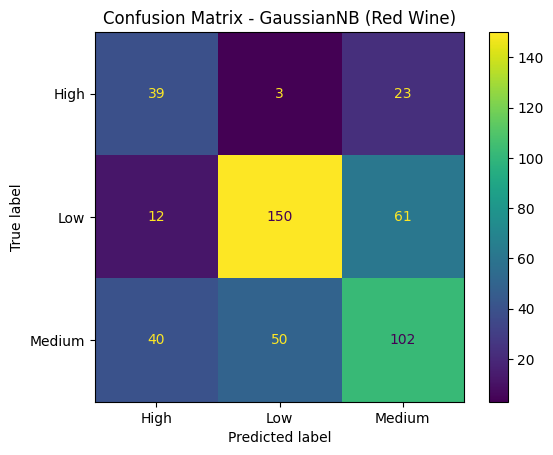


=== Logistic Regression (Scaled) (Red Wine) ===
Accuracy: 0.61875

Classification Report:
              precision    recall  f1-score   support

        High       0.50      0.32      0.39        65
         Low       0.71      0.77      0.74       223
      Medium       0.53      0.55      0.54       192

    accuracy                           0.62       480
   macro avg       0.58      0.55      0.56       480
weighted avg       0.61      0.62      0.61       480



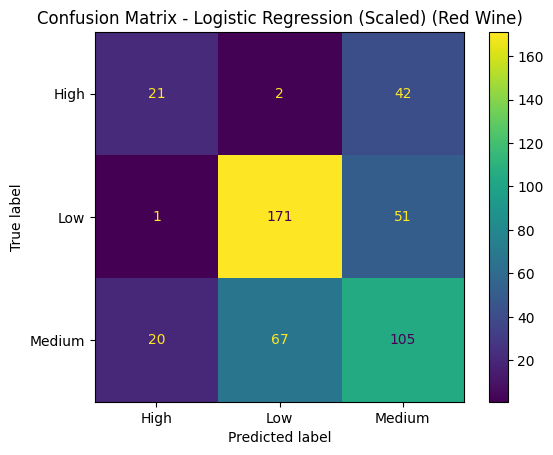


=== Random Forest (Red Wine) ===
Accuracy: 0.7291666666666666

Classification Report:
              precision    recall  f1-score   support

        High       0.67      0.54      0.60        65
         Low       0.80      0.80      0.80       223
      Medium       0.67      0.71      0.69       192

    accuracy                           0.73       480
   macro avg       0.71      0.68      0.70       480
weighted avg       0.73      0.73      0.73       480



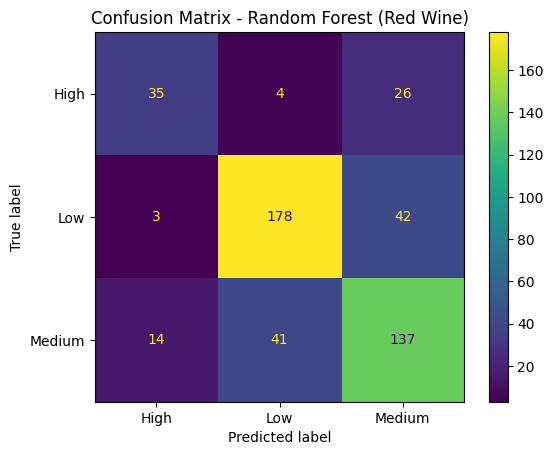


Accuracy Summary: {'GaussianNB': 0.60625, 'LogisticRegression': 0.61875, 'RandomForest': 0.7291666666666666}


In [ ]:
results = {}

results["GaussianNB"] = evaluate_model(
    GaussianNB(),
    "GaussianNB",
    X_train, X_test, y_train, y_test
)

# Logistic Regression with scaling to ensure convergence
log_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=3000,
        solver="lbfgs",
        random_state=42
    ))
])

results["LogisticRegression"] = evaluate_model(
    log_reg,
    "Logistic Regression (Scaled)",
    X_train, X_test, y_train, y_test
)

results["RandomForest"] = evaluate_model(
    RandomForestClassifier(n_estimators=300, random_state=42),
    "Random Forest",
    X_train, X_test, y_train, y_test
)

print("\nAccuracy Summary:", results)

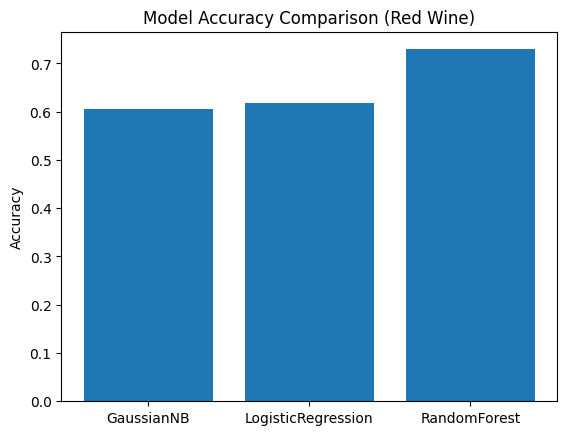

In [ ]:
plt.figure()
plt.bar(list(results.keys()), list(results.values()))
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison (Red Wine)")
plt.show()

## Discussion (brief)

- The regrouping converts the original integer quality scores into 3 categories, enabling a clearer classification task.
- GaussianNB provides a simple probabilistic baseline.
- Logistic Regression provides a strong linear baseline.
- Random Forest typically performs best when relationships are non-linear.

The confusion matrices and class-wise precision/recall/F1 explain which quality categories are most commonly confused.